In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk
import shap

from sklearn.metrics import roc_auc_score, average_precision_score

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), os.pardir)))
from customFunctions.utils import binary_auROC

In [2]:
mithril_features = pd.read_csv("../checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
mithril_features

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,bulge,stem,hairpin,loop,unpaired_frequency,closest_modification,closest_modification_2D,OEUF_score
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,-0.802033,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,-5.816984,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,-3.647059,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,-5.594591,1,0,1,0,0,0.014503,7,7.0,0.358
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,0.933444,1,0,1,0,0,0.014503,7,7.0,0.358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,-3.407268,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,-5.822305,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,-4.319805,0,0,1,0,0,0.003610,8,6.0,0.470


In [3]:
embedding = pd.read_csv("../data/Mithril_msm_embedding.csv", index_col=0)
embedding.index.name = "Mithril_id"
embedding.columns = "channel_"+embedding.columns.astype(str)
embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,-0.046571,-0.464829,-1.071173,0.706031,0.254538,-0.839300,-0.785148,-0.686940,-0.066750,-0.083101,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,-0.094558,-0.843313,-0.774938,0.836958,-0.283595,-0.961378,-0.578084,-0.701949,0.039039,-0.158005,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,0.050315,-0.794720,-0.958813,0.551639,-0.071321,-0.767290,-0.558026,-0.843187,0.249865,-0.380568,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,-0.271729,-0.401465,-0.722368,0.715860,-0.171587,-0.678559,-0.540892,-0.339579,-0.256668,-0.268223,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,-0.189935,-0.290123,-0.115013,0.859563,-0.127386,-0.715655,-0.411798,-0.926073,-0.151554,-0.170612,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.085203,0.720789,0.258117,-0.241561,0.276256,0.001175,0.117050,-0.357717,0.238088,0.165467,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,-0.516000,0.442102,0.331330,0.229251,-0.081880,-0.531516,0.226194,-0.564276,0.209845,-0.133919,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,0.318094,0.357954,-0.837745,-0.545639,-0.157910,0.394076,-1.226594,-0.005673,0.406269,-0.306028,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [ ]:
X = mithril_features.join(embedding)
X.shape

(4521, 788)

In [5]:
tuned_model_svc = pk.load(open("../checkpoints/candidate_models/model_svc.pk", "rb"))
tuned_model_svc

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x71927370e8e0>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x71927372ff60>, verbose=2)

In [10]:
X_transformed = tuned_model_svc.best_estimator_[:-1].transform(X)
X_transformed.index = X.index
X_transformed

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,unpaired_frequency,closest_modification,OEUF_score,PC_1,PC_2,PC_3,PC_4,PC_5
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.176727,0.715253,-1.452850,1.545045,1.480352,0.954134,-0.299044,0.342769,-0.680620,1.598726,0.214831,-1.767824,-1.060829,0.041083,-0.450042,8.424408,0.856009,2.124207,1.073375,-2.424781
MITHRIL.1729,1.176727,0.715253,-1.452850,1.545045,1.430802,0.954134,-0.934654,0.342769,-0.680620,1.598726,-0.516145,-1.767824,-1.060829,0.041083,-0.450042,6.084116,0.545429,3.145983,0.805294,-2.821490
MITHRIL.1730,1.176727,0.715253,-1.452850,1.545045,1.430802,0.954134,-0.863655,0.342769,-0.680620,1.598726,-0.199858,-1.767824,-1.060829,0.041083,-0.450042,9.303537,-0.883934,1.786964,0.423214,-2.733128
MITHRIL.1731,1.153573,0.226994,-1.400037,1.545045,1.728104,-0.121783,-0.931273,0.342769,0.014163,0.746405,-0.483729,-1.723501,-1.054587,-0.094018,-0.728020,0.439282,3.921170,-1.328000,0.343577,-0.465627
MITHRIL.1732,1.153573,0.226994,-1.400037,1.545045,1.728104,-0.121783,1.229124,0.342769,0.014163,0.746405,0.467793,-1.723501,-1.054587,-0.094018,-0.728020,-2.713398,3.725281,-0.327298,-1.194881,-0.959551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.176727,0.686348,1.499799,-0.561018,-0.055708,1.369244,-0.847149,0.342769,-1.644813,1.598726,-0.164907,-1.723501,-1.065598,-0.094018,-0.728020,-2.575146,-3.879147,1.561551,-1.175544,-0.145825
MITHRIL.48240,1.176727,0.686348,1.499799,1.637960,1.926305,1.369244,-0.934729,0.342769,-1.644813,1.598726,-0.516921,-1.723501,-1.065598,-0.094018,-0.728020,-2.541791,-2.499284,2.950000,-1.056045,-2.065907
MITHRIL.48241,1.176727,1.248556,1.477411,-0.561018,0.538896,1.452837,-0.897676,0.342769,-1.988527,1.598726,-0.297917,-1.767824,-1.078029,0.041083,-0.450042,4.741607,-0.190472,-0.948027,-1.550220,1.576086


In [13]:
explainer = shap.Explainer(
    lambda x: tuned_model_svc.best_estimator_[-1].estimator.predict_proba(x)[:,1],
    X_transformed
)
explainer

In [ ]:
#################################################
################# This is huge! #################
#### consider directly loading the pk output ####
#################################################
shap_values = explainer(X_transformed)
pk.dump(shap_values, open("../checkpoints/shap_values.pk", "wb"))
shap_values

PermutationExplainer explainer: 4522it [13:14:44, 10.55s/it]                            


.values =
array([[ 0.02603027,  0.01027484, -0.07136036, ...,  0.01038669,
        -0.01108692,  0.00098236],
       [ 0.0283104 ,  0.01067308, -0.07853886, ...,  0.01984199,
        -0.00993502, -0.00142979],
       [ 0.02430152,  0.01022929, -0.0718941 , ...,  0.00960183,
        -0.00456462, -0.00412577],
       ...,
       [ 0.03507034,  0.02230946,  0.05135978, ..., -0.00429501,
         0.03362231,  0.02032631],
       [ 0.0341897 ,  0.02186881,  0.0585517 , ..., -0.00933509,
        -0.02686218,  0.01212894],
       [ 0.03248965,  0.02055751,  0.05189003, ..., -0.00529243,
         0.01722437,  0.00664999]])

.base_values =
array([0.53454302, 0.53454302, 0.53454302, ..., 0.53454302, 0.53454302,
       0.53454302])

.data =
array([[ 1.17672734,  0.71525313, -1.45285028, ...,  2.12420729,
         1.07337485, -2.42478083],
       [ 1.17672734,  0.71525313, -1.45285028, ...,  3.14598257,
         0.80529375, -2.82149045],
       [ 1.17672734,  0.71525313, -1.45285028, ...,  1.78696

In [15]:
shap_values = pk.load(open("../checkpoints/shap_values.pk", "rb"))
shap_values

.values =
array([[ 0.02603027,  0.01027484, -0.07136036, ...,  0.01038669,
        -0.01108692,  0.00098236],
       [ 0.0283104 ,  0.01067308, -0.07853886, ...,  0.01984199,
        -0.00993502, -0.00142979],
       [ 0.02430152,  0.01022929, -0.0718941 , ...,  0.00960183,
        -0.00456462, -0.00412577],
       ...,
       [ 0.03507034,  0.02230946,  0.05135978, ..., -0.00429501,
         0.03362231,  0.02032631],
       [ 0.0341897 ,  0.02186881,  0.0585517 , ..., -0.00933509,
        -0.02686218,  0.01212894],
       [ 0.03248965,  0.02055751,  0.05189003, ..., -0.00529243,
         0.01722437,  0.00664999]])

.base_values =
array([0.53454302, 0.53454302, 0.53454302, ..., 0.53454302, 0.53454302,
       0.53454302])

.data =
array([[ 1.17672734,  0.71525313, -1.45285028, ...,  2.12420729,
         1.07337485, -2.42478083],
       [ 1.17672734,  0.71525313, -1.45285028, ...,  3.14598257,
         0.80529375, -2.82149045],
       [ 1.17672734,  0.71525313, -1.45285028, ...,  1.78696

/tmp/ipykernel_20424/2307125720.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_transformed)


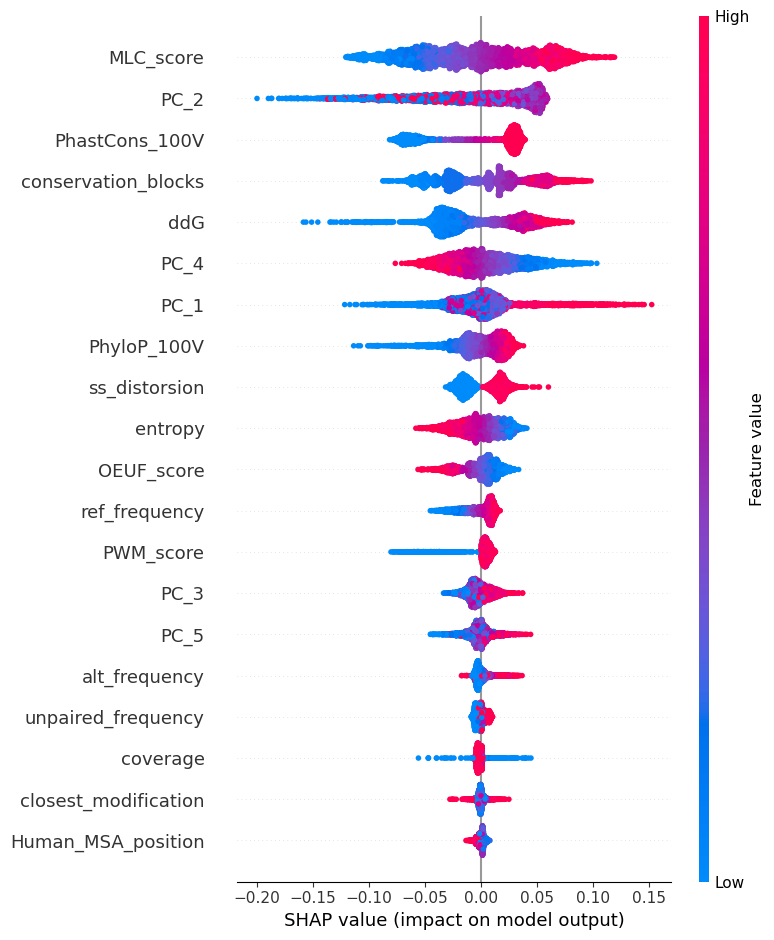

In [16]:
shap.summary_plot(shap_values, X_transformed)

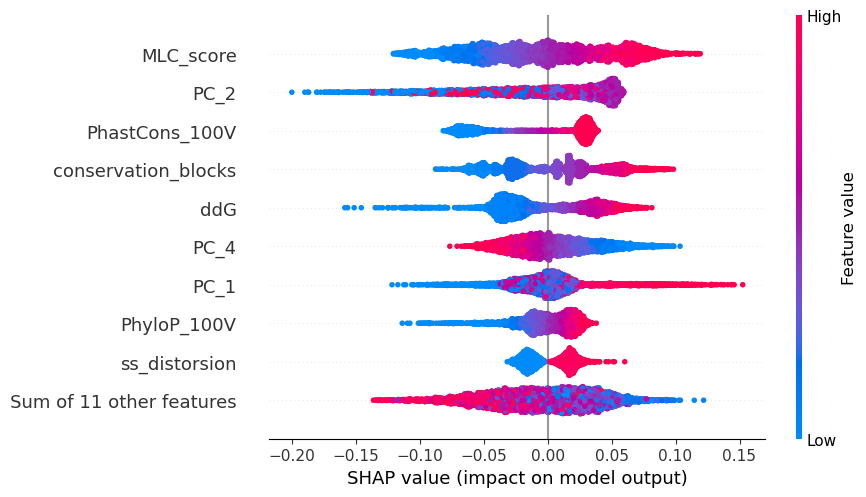

In [17]:
shap.plots.beeswarm(shap_values)

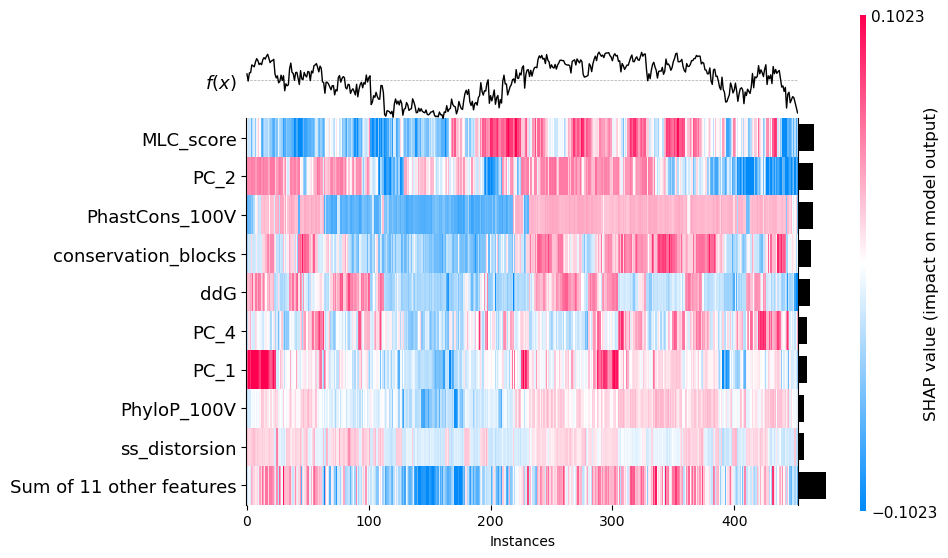

<Axes: xlabel='Instances'>

In [18]:
shap.plots.heatmap(shap_values[::10])

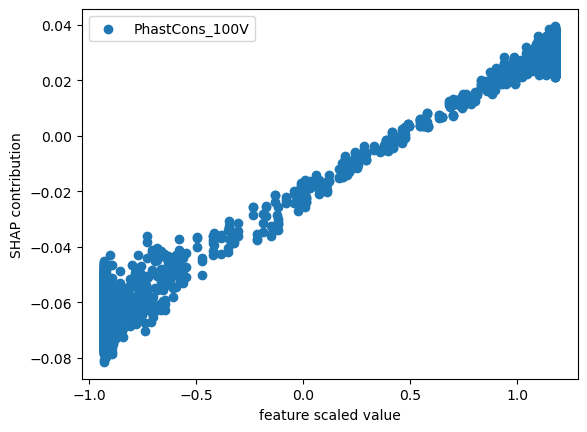

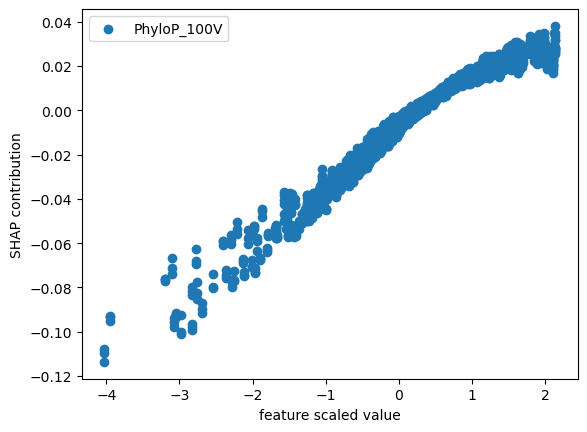

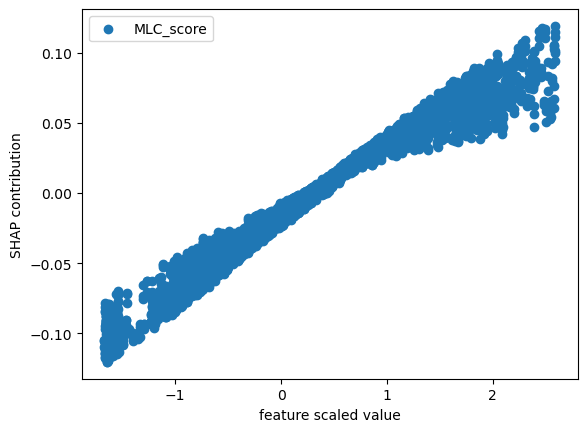

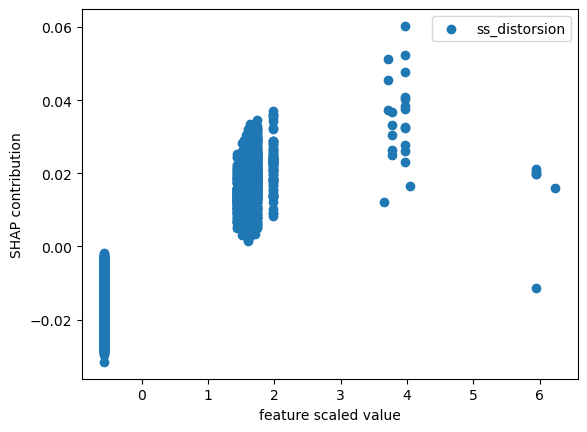

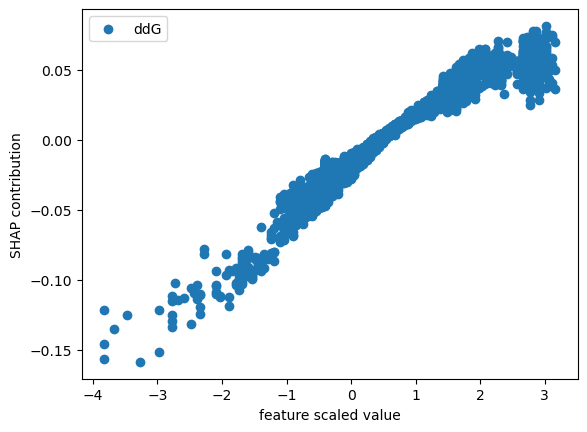

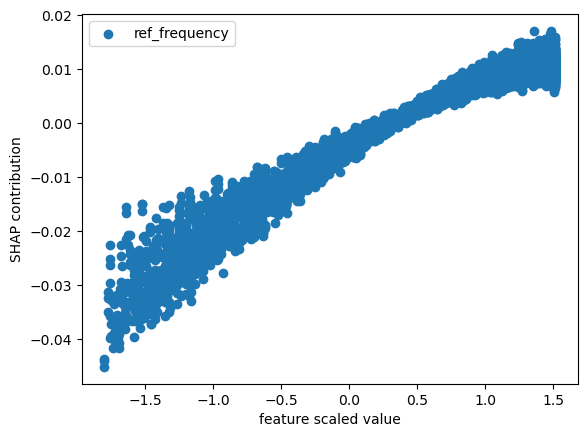

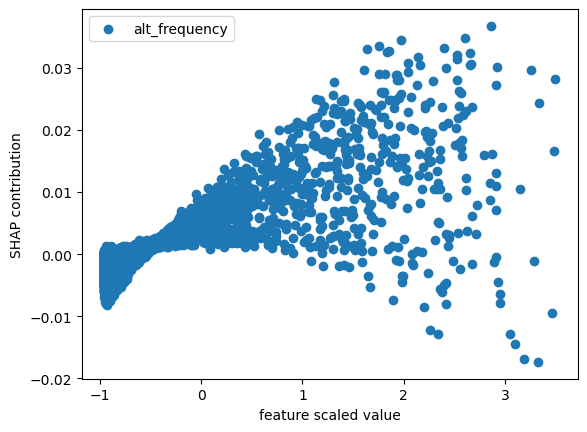

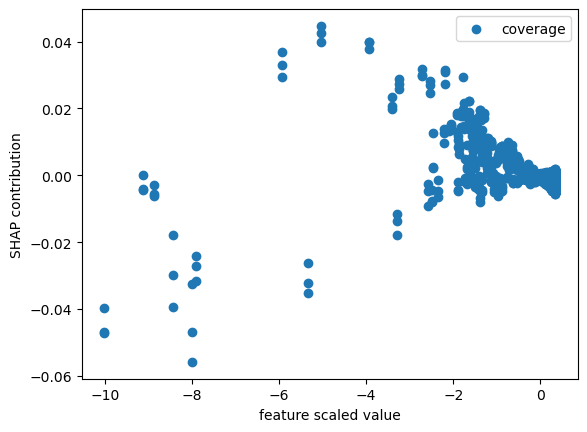

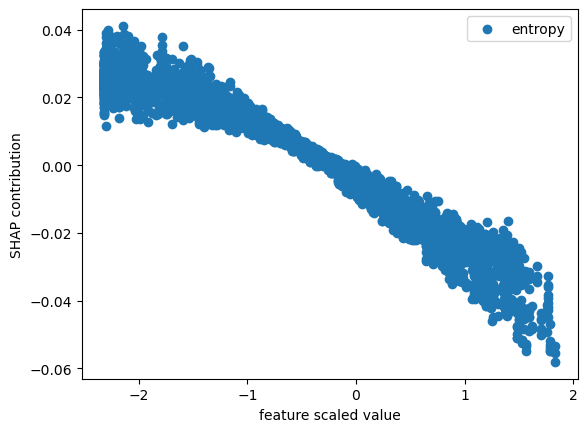

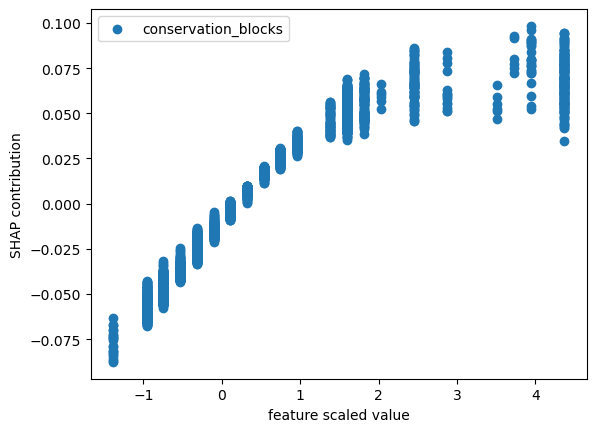

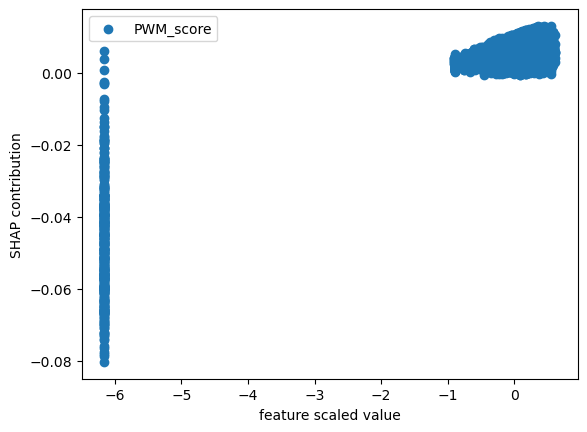

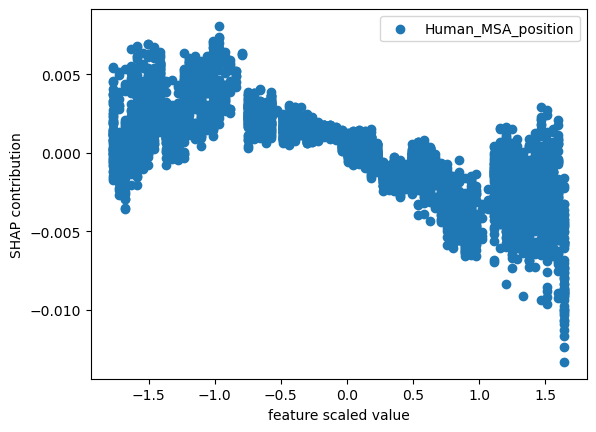

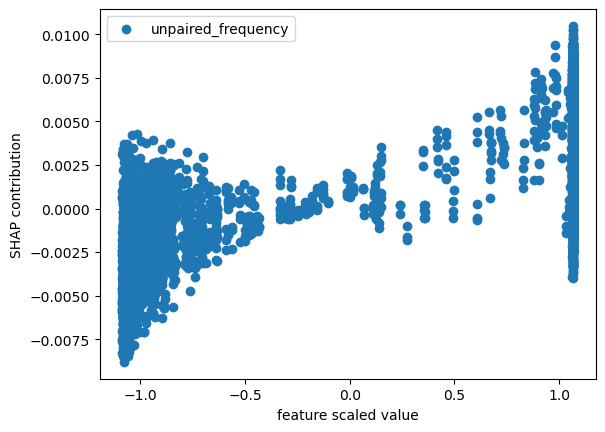

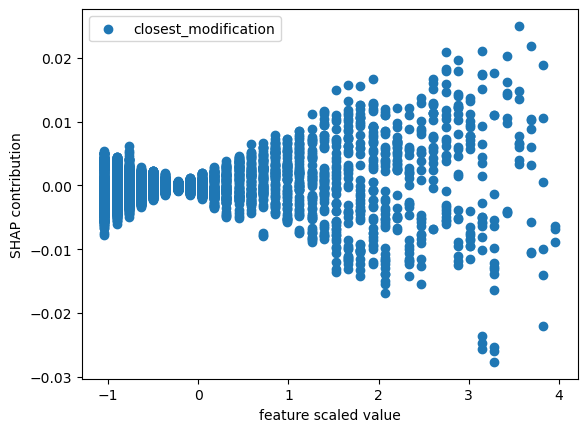

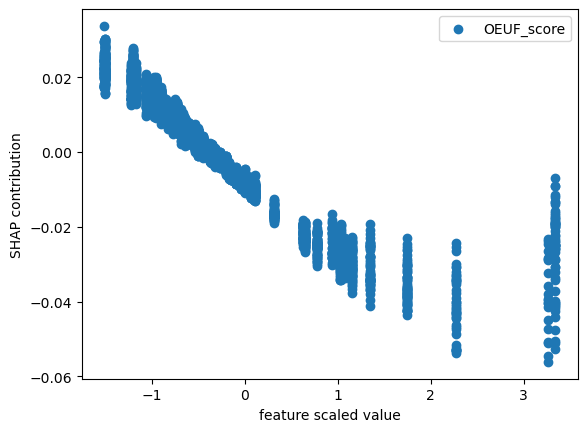

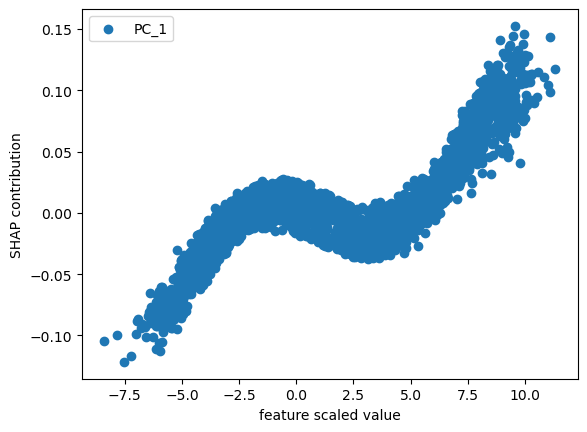

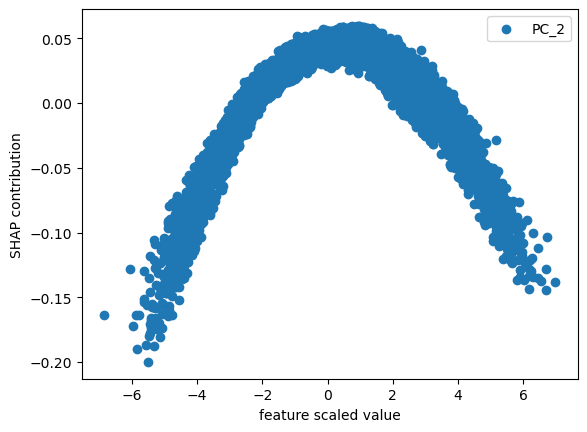

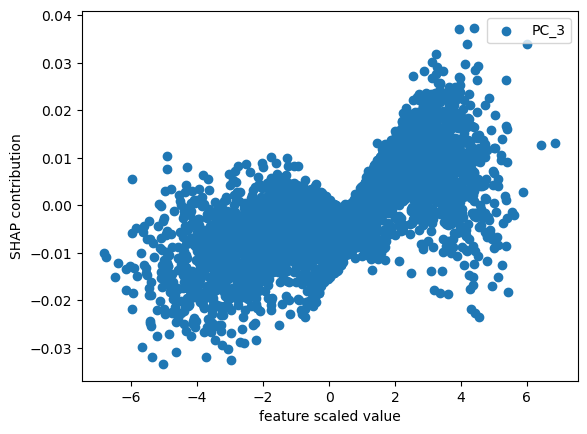

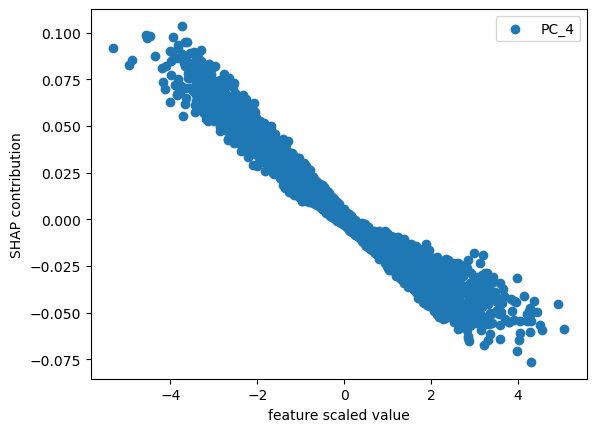

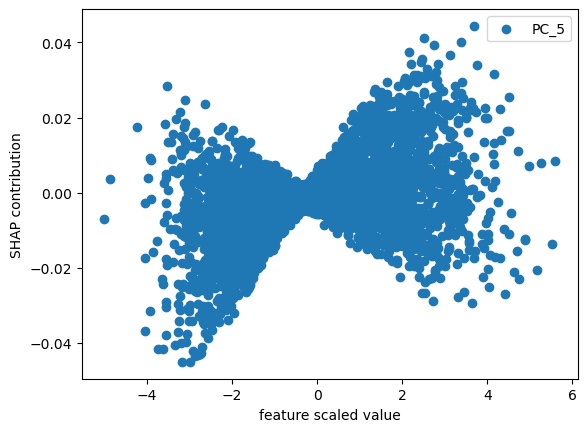

In [20]:
for i, feature in enumerate(X_transformed.columns):
    idx = np.argsort(shap_values[:,i].data)
    plt.scatter(shap_values[idx,i].data, shap_values[idx,i].values, label=feature)
    plt.legend()
    plt.xlabel("feature scaled value")
    plt.ylabel("SHAP contribution")
    plt.show()

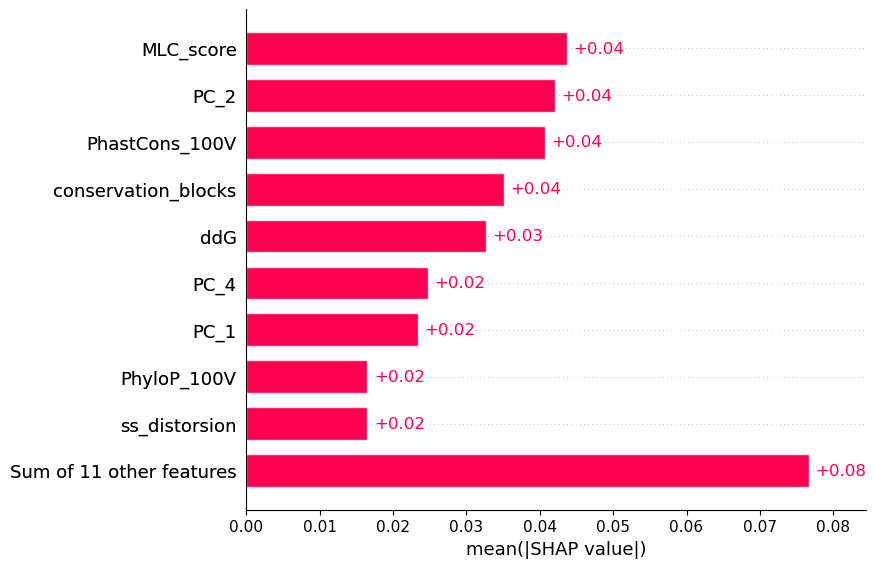

In [21]:
shap.plots.bar(shap_values)

Text(0.5, 0, 'E[|SHAP|]')

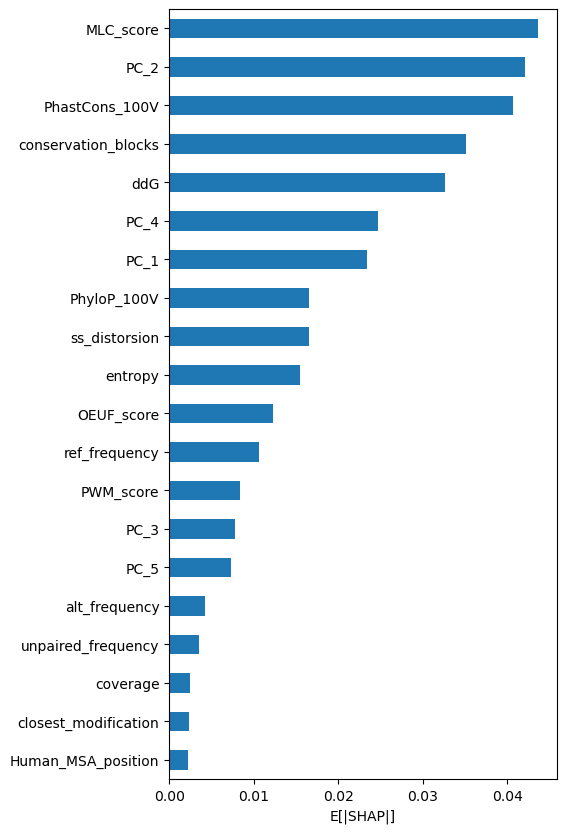

In [22]:
plt.figure(figsize=(5,10))
pd.Series(np.abs(shap_values.values).mean(axis=0), index=X_transformed.columns).sort_values(ascending=True).plot.barh()
plt.xlabel("E[|SHAP|]")

In [23]:
# aggregate the contributions of RNA-MSM PCs

shap_values_df = pd.DataFrame(shap_values.values, index=X_transformed.index, columns=X_transformed.columns)
shap_values_df["RNA_MSM"] = shap_values_df.loc[:, shap_values_df.columns.str.match("PC_")].sum(axis=1).rename("RNA_MSM")
shap_values_df = shap_values_df.loc[:, ~shap_values_df.columns.str.match("PC_")]
shap_values_df

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,unpaired_frequency,closest_modification,OEUF_score,RNA_MSM
Mithril_id,,,,,,,,,,,,,,,,
MITHRIL.1728,0.026030,0.010275,-0.071360,0.018107,0.032736,0.006480,0.003747,0.001171,0.008029,0.047008,0.011210,0.000189,-0.003434,0.000733,0.003400,0.151780
MITHRIL.1729,0.028310,0.010673,-0.078539,0.017598,0.032488,0.006986,-0.003353,0.000688,0.008943,0.051627,0.005540,0.001089,-0.005143,0.000417,0.003426,0.088273
MITHRIL.1730,0.024302,0.010229,-0.071894,0.015742,0.028347,0.005903,-0.002523,0.000923,0.007771,0.045526,0.008131,-0.000447,-0.004289,0.000488,0.002933,0.161785
MITHRIL.1731,0.032253,-0.000457,-0.102766,0.019652,0.044360,-0.005713,-0.005026,-0.001756,-0.004246,0.026917,0.003704,0.000110,-0.000756,0.000291,0.010158,-0.030302
MITHRIL.1732,0.030945,0.000692,-0.100109,0.026612,0.050660,-0.004567,0.020421,-0.002483,-0.002200,0.029037,0.009208,-0.000497,0.001799,0.000644,0.009814,0.027806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.029336,0.010806,0.061857,-0.011713,-0.012163,0.010465,-0.003394,-0.003887,0.021826,0.056782,0.005054,0.002781,-0.007333,-0.000114,0.006234,-0.035372
MITHRIL.48240,0.025405,0.010347,0.052856,0.015333,0.037720,0.008405,-0.005439,-0.003132,0.015813,0.052290,0.004959,-0.000173,-0.004311,0.000355,0.005936,0.022374
MITHRIL.48241,0.035070,0.022309,0.051360,-0.006276,0.006167,0.013585,-0.000385,-0.000247,0.030270,0.045473,0.007555,0.001882,-0.006789,0.000724,0.003819,0.102346


In [24]:
shap_values_df.abs().sum()

PhastCons_100V          183.968122
PhyloP_100V              74.610918
MLC_score               197.381881
ss_distorsion            74.496791
ddG                     147.568547
ref_frequency            47.778908
alt_frequency            18.947696
coverage                 11.289940
entropy                  70.073571
conservation_blocks     158.558726
PWM_score                37.847587
Human_MSA_position       10.186489
unpaired_frequency       15.767623
closest_modification     10.386532
OEUF_score               55.633605
RNA_MSM                 293.016114
dtype: float64

In [25]:
# normalizing to have feature importances sum to 1
shap_importances = shap_values_df.abs().sum().rename("shap_importances")
shap_importances /= shap_importances.sum()
shap_importances

PhastCons_100V          0.130704
PhyloP_100V             0.053009
MLC_score               0.140234
ss_distorsion           0.052928
ddG                     0.104843
ref_frequency           0.033946
alt_frequency           0.013462
coverage                0.008021
entropy                 0.049785
conservation_blocks     0.112652
PWM_score               0.026890
Human_MSA_position      0.007237
unpaired_frequency      0.011202
closest_modification    0.007379
OEUF_score              0.039526
RNA_MSM                 0.208180
Name: shap_importances, dtype: float64

In [26]:
# original preprocessing feature selection importances

tree_training_importance = pd.Series(tuned_model_svc.best_estimator_[0]["feature_selection"].estimator_.feature_importances_, index=mithril_features.columns).rename("tree_training_importance")
tree_training_importance

PhastCons_100V             2.442173e-01
PhyloP_100V                7.166909e-02
MLC_score                  1.164619e-01
ss_distorsion              3.350041e-02
ddG                        9.309108e-02
ref_frequency              3.790409e-02
alt_frequency              3.273588e-02
coverage                   3.830918e-02
entropy                    1.741323e-02
conservation_blocks        8.895542e-02
PWM_score                  6.825934e-02
Human_MSA_position         2.912328e-02
bulge                      1.176328e-16
stem                       2.829654e-18
hairpin                    0.000000e+00
loop                       1.735419e-03
unpaired_frequency         4.523331e-02
closest_modification       3.105308e-02
closest_modification_2D    3.981768e-03
OEUF_score                 4.635630e-02
Name: tree_training_importance, dtype: float64

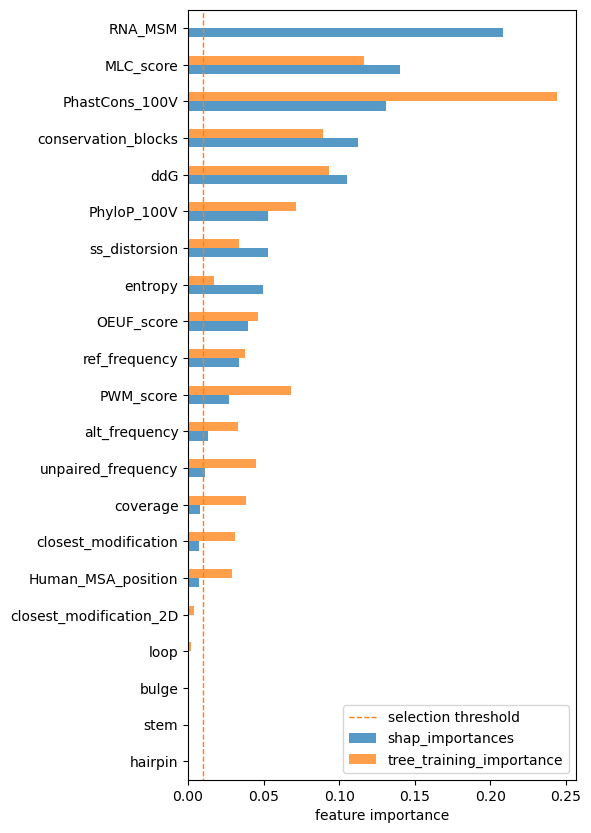

In [27]:
plt.figure(figsize=(5,10))
ax = plt.subplot(111)
shap_importances.to_frame().join(tree_training_importance, how="outer").fillna(0.).sort_values(["shap_importances", "tree_training_importance"], ascending=True).plot.barh(ax=ax, alpha=.75)
plt.vlines(
    tuned_model_svc.best_estimator_[0]["feature_selection"].threshold,
    -1, len(X.columns),
    ls="--", color="C1", lw=1,
    label="selection threshold"
)
plt.legend(loc="lower right")
plt.xlabel("feature importance")
plt.show()

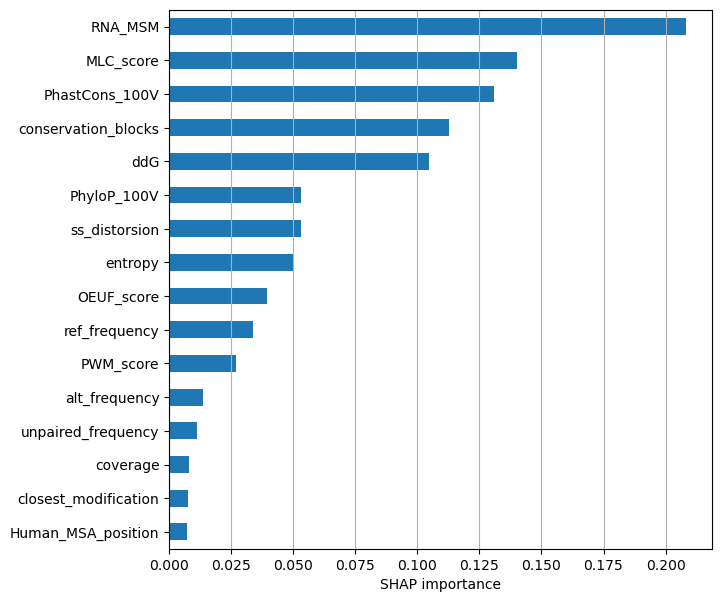

In [28]:
plt.figure(figsize=(7,7))
ax = plt.subplot(111)
shap_importances.sort_values().plot.barh(ax=ax)
plt.grid(axis="x")
plt.xlabel("SHAP importance")
plt.show()

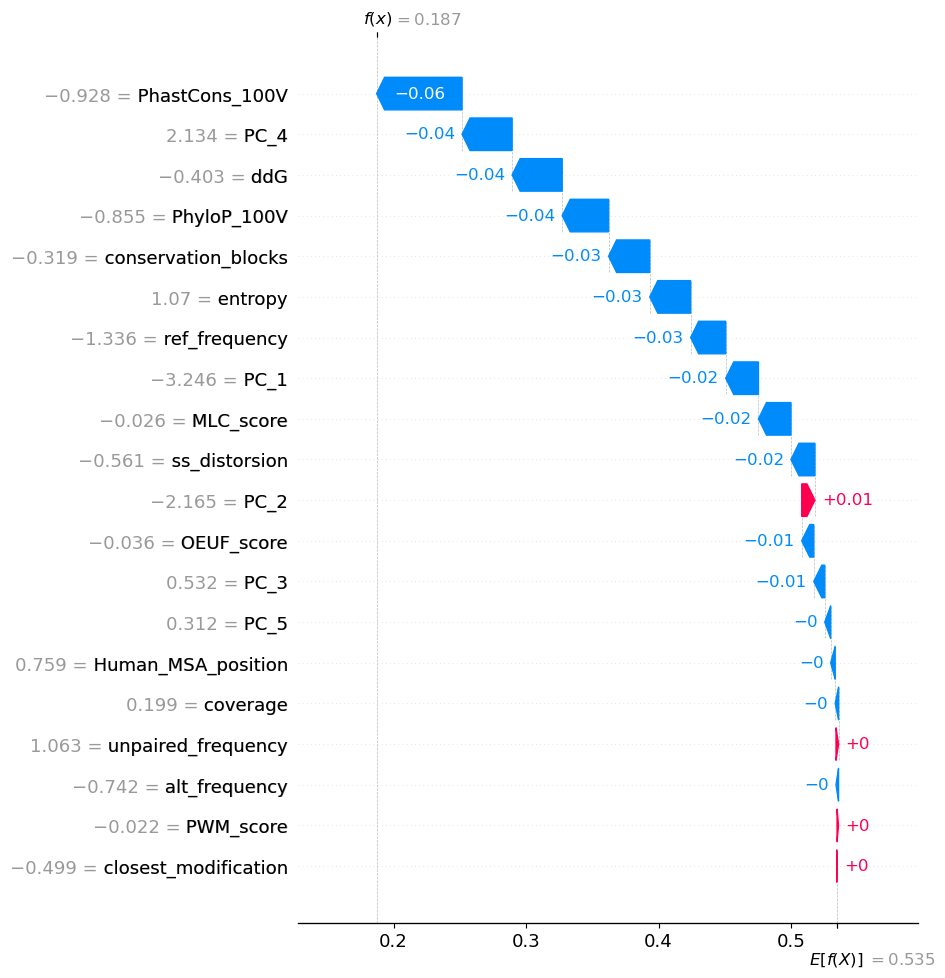

In [29]:
shap.plots.waterfall(shap_values[shap_values_df.index=="MITHRIL.25043"][0], max_display=100)

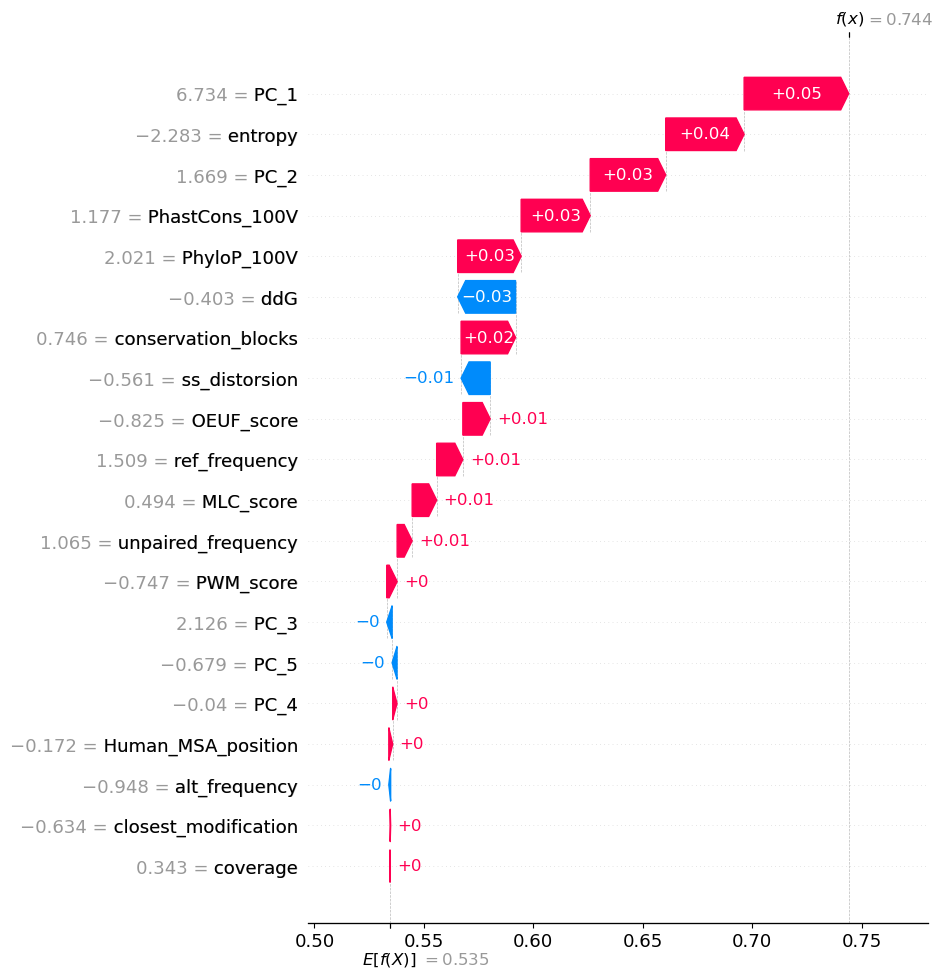

In [30]:
shap.plots.waterfall(shap_values[shap_values_df.index=="MITHRIL.1830"][0], max_display=100)

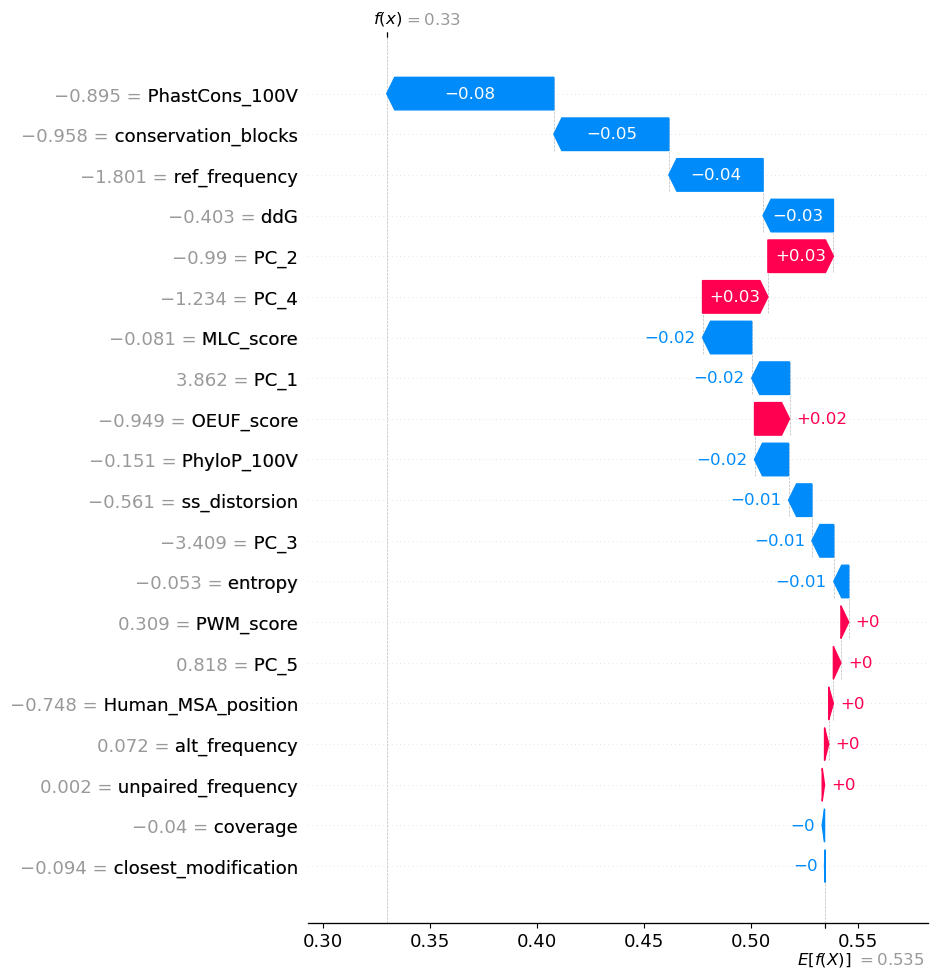

In [31]:
shap.plots.waterfall(shap_values[shap_values_df.index=="MITHRIL.22501"][0], max_display=100)

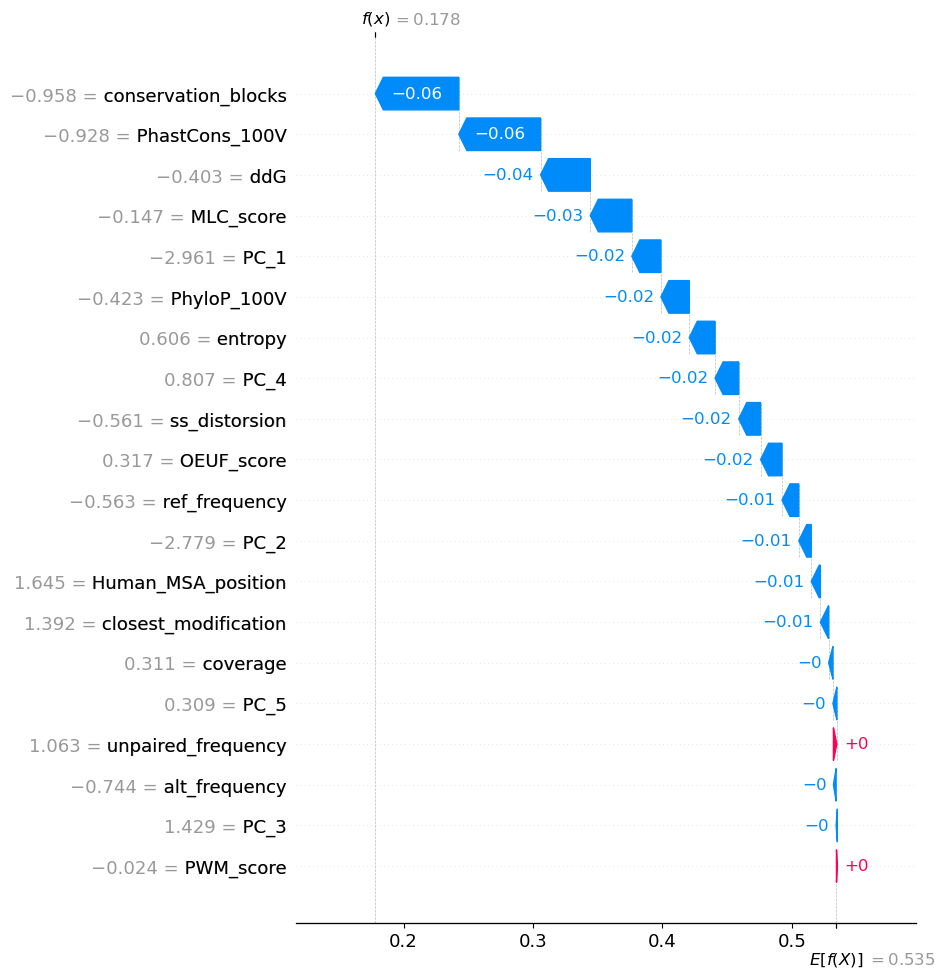

In [32]:
shap.plots.waterfall(shap_values[shap_values_df.index=="MITHRIL.44195"][0], max_display=100)